# Titanic Survival Prediction

## Model Training and Evaluation

Goal:
Train machine learning models using engineered features and generate a Kaggle-ready submission.

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn catboost joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from catboost import CatBoostClassifier

In [4]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.shape, test.shape

((891, 12), (418, 11))

In [6]:
test_ids = test["PassengerId"]

In [7]:
full = pd.concat(
    [train.drop("Survived", axis=1), test],
    axis=0,
    ignore_index=True
)

In [8]:
full["Title"] = full["Name"].str.extract(
    " ([A-Za-z]+)\.",
    expand=False
)

rare_titles = [
    "Lady","Countess","Capt","Col",
    "Don","Dr","Major","Rev",
    "Sir","Jonkheer","Dona"
]

full["Title"] = full["Title"].replace(
    rare_titles,
    "Rare"
)

full["Title"] = full["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})

In [9]:
full["FamilySize"] = (
    full["SibSp"]
    + full["Parch"]
    + 1
)

full["IsAlone"] = (
    full["FamilySize"] == 1
).astype(int)

In [10]:
full["CabinKnown"] = (
    full["Cabin"]
    .notnull()
    .astype(int)
)

In [11]:
ticket_counts = (
    full["Ticket"]
    .value_counts()
)

full["TicketGroupSize"] = (
    full["Ticket"]
    .map(ticket_counts)
)

In [12]:
full["Age"] = (
    full.groupby("Title")["Age"]
    .transform(
        lambda x: x.fillna(x.median())
    )
)

full["Fare"] = (
    full["Fare"]
    .fillna(full["Fare"].median())
)

full["Embarked"] = (
    full["Embarked"]
    .fillna(
        full["Embarked"].mode()[0]
    )
)

In [13]:
full["AgeBand"] = pd.cut(
    full["Age"],
    bins=5,
    labels=False
)

full["FareBand"] = pd.qcut(
    full["Fare"],
    q=4,
    labels=False,
    duplicates="drop"
)

In [14]:
full.drop(
    [
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    axis=1,
    inplace=True
)

In [15]:
X_train = full.iloc[:len(train)]

X_test = full.iloc[len(train):]

y_train = train["Survived"]

In [16]:
categorical_cols = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numerical_cols
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_cols
        )
    ]
)

In [18]:
model = CatBoostClassifier(
    depth=6,
    learning_rate=0.03,
    iterations=1000,
    verbose=0,
    random_state=42,
    task_type="GPU",
    devices='0'
)

In [19]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(scores)
print()
print(
    f"Mean Accuracy: {scores.mean():.4f}"
)

[0.87150838 0.83707865 0.80898876 0.84269663 0.85393258]

Mean Accuracy: 0.8428


In [21]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone',
                                                   'CabinKnown',
                                                   'TicketGroupSize', 'AgeBand',
                                                   'FareBand']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Title'])])),
                ('model',
                 CatBoostClassifier(depth=6, devices='0', iterations=1000, learning_rate=0.03, random_state=42, task_type='GPU', verbose=0))])

In [22]:
preds = pipeline.predict(
    X_test
)

In [23]:
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": preds.astype(int)
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [24]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(
    "Submission file saved."
)

Submission file saved.


In [25]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
feature_names = (
    numerical_cols
    +
    list(
        pipeline.named_steps["prep"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(
            categorical_cols
        )
    )
)

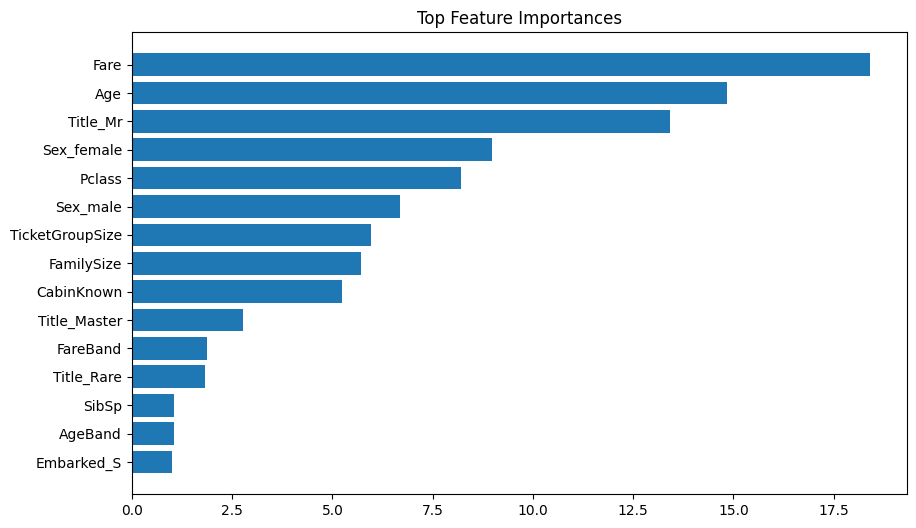

In [27]:
import matplotlib.pyplot as plt

importance = (
    pipeline.named_steps["model"]
    .feature_importances_
)

fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

fi = fi.sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

plt.barh(
    fi["Feature"],
    fi["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Feature Importances"
)

plt.show()